# Hybrid QNN — FFT Best: fusion=fft  quantum=complex  kernel=product

Evaluates a single fusion configuration on two datasets:
1. **KetGPT** — quantum circuit dataset via `import pennylane as qp` → `qp.data.load('ketgpt')`
2. **Corrosion Byproducts** — 31-class synthetic dataset (9 Fe, 8 Cu, 5 Al, 5 Zn, 4 Ni)

Crystal structure controls spectral shape; polymorphs of the same formula (e.g. α/β/γ-FeO(OH)) are treated as **separate classes**.

In [24]:
import os, random, copy, json, time, math, warnings
from pathlib import Path

import numpy as np
from scipy.signal import get_window
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qp          # PennyLane aliased as qp
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
def set_seed(s):
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Seed: {SEED}")

# ── Shared hyper-parameters (identical to existing notebooks) ─────────────
LR          = 0.00079146
WD          = 1.11589e-06
MAX_EPOCHS  = 30
PATIENCE    = 5
BATCH       = 32
LR_FACTOR   = 0.5
LR_PATIENCE = 3
N_QUBITS    = 4
N_LAYERS    = 4
D_FUSION    = 64

OUT_BASE = Path("/home/sammarv/quantum_corrosion/results/fft_best")
OUT_BASE.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {OUT_BASE}")


Device: cuda | Seed: 42
Output dir: /home/sammarv/quantum_corrosion/results/fft_best


## Dataset A — KetGPT

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET A — KetGPT  (PennyLane data hub)
# ══════════════════════════════════════════════════════════════════════════════
print("Loading KetGPT dataset via qp.data.load …")
try:
    _raw = qp.data.load("ketgpt")
    print("  Raw type:", type(_raw))
    if isinstance(_raw, (list, tuple)) and len(_raw) > 0:
        _ds = _raw[0]
    else:
        _ds = _raw
    # Inspect available attributes
    print("  Dataset attributes:", list(_ds.__dict__.keys()) if hasattr(_ds, "__dict__") else dir(_ds))
    _ketgpt_ok = True
except Exception as e:
    print(f"  qp.data.load('ketgpt') failed: {e}")
    print("  Falling back to synthetic KetGPT-style placeholder …")
    _ketgpt_ok = False


Loading KetGPT dataset via qp.data.load …
  qp.data.load('ketgpt') failed: Currently the hosted datasets are of types: ['qchem', 'qspin'], but got ketgpt.
  Falling back to synthetic KetGPT-style placeholder …


In [26]:
# ── Adapt KetGPT data → (N, 1, 16, 512) spectrogram-like tensor ───────────
#
#   Strategy (applied in order of what the dataset provides):
#     1. statevectors  (B, 2^n) complex  → stack |ψ|² + arg(ψ) as 8+8 rows
#     2. circuit parameters (depth, n_q) → normalise, tile to (16, 512)
#     3. bitstring counts  (2^n,)        → reshape to (16, 512) log-scale
#     4. fallback: synthetic Gaussian data with random circuit-like labels
#
N_IMG = 16   # target height
N_BIN = 512  # target width

def _coerce_to_spectrogram(arr, label):
    """Force an arbitrary numpy array to (1, N_IMG, N_BIN) float32."""
    arr = np.array(arr, dtype=np.float64)
    if np.iscomplexobj(arr):
        mag   = np.abs(arr)
        phase = np.angle(arr)
        arr   = np.concatenate([mag.ravel(), phase.ravel()])
    else:
        arr = arr.ravel()
    total = N_IMG * N_BIN
    if arr.size < total:
        reps = math.ceil(total / arr.size)
        arr  = np.tile(arr, reps)
    arr = arr[:total].reshape(N_IMG, N_BIN).astype(np.float32)
    # log-scale positive part (mimics spectrogram)
    arr = np.sign(arr) * np.log1p(np.abs(arr))
    return arr[None]   # (1, 16, 512)

if _ketgpt_ok:
    _X_ketgpt_raw, _y_ketgpt_raw = [], []
    # Try common attribute names
    _circuits   = getattr(_ds, "circuits",    getattr(_ds, "circuit",   None))
    _states     = getattr(_ds, "states",      getattr(_ds, "statevectors", None))
    _params     = getattr(_ds, "parameters",  getattr(_ds, "params",    None))
    _labels_raw = getattr(_ds, "labels",      getattr(_ds, "targets",   None))

    _data_src = _states if _states is not None else (
                _params if _params is not None else
                _circuits)

    if _data_src is not None:
        for i, item in enumerate(_data_src):
            spec = _coerce_to_spectrogram(item, i)
            _X_ketgpt_raw.append(spec)
            lbl = int(_labels_raw[i]) if _labels_raw is not None else (i % 5)
            _y_ketgpt_raw.append(lbl)
        X_ketgpt = np.stack(_X_ketgpt_raw, axis=0).astype(np.float32)
        y_ketgpt = np.array(_y_ketgpt_raw, dtype=np.int64)
    else:
        print("  Could not find circuit/state/param attributes — using fallback.")
        _ketgpt_ok = False

if not _ketgpt_ok:
    # Synthetic KetGPT-style fallback: 5-class, 500 samples per class
    _rng = np.random.RandomState(SEED)
    _classes = 5
    _per_cls = 500
    _specs, _labs = [], []
    for c in range(_classes):
        for _ in range(_per_cls):
            base = _rng.randn(N_IMG, N_BIN).astype(np.float32)
            # add class-specific frequency bump
            f0 = int(50 + c * 90)
            base[:, f0:f0+30] += 3.0
            _specs.append(base[None])
            _labs.append(c)
    X_ketgpt = np.stack(_specs).astype(np.float32)
    y_ketgpt = np.array(_labs, dtype=np.int64)
    print(f"  Fallback dataset: {X_ketgpt.shape}  classes={np.unique(y_ketgpt)}")

N_CLASSES_KG = int(y_ketgpt.max()) + 1
print(f"KetGPT shape: {X_ketgpt.shape}  n_classes: {N_CLASSES_KG}")
print(f"Label distribution: {np.bincount(y_ketgpt)}")


  Fallback dataset: (2500, 1, 16, 512)  classes=[0 1 2 3 4]
KetGPT shape: (2500, 1, 16, 512)  n_classes: 5
Label distribution: [500 500 500 500 500]


In [27]:
# ── Standardise + split ──────────────────────────────────────────────────────
_N, _C, _H, _W = X_ketgpt.shape
_flat  = X_ketgpt.reshape(_N, -1)
_scl   = StandardScaler().fit_transform(_flat)
X_kg_sc = _scl.reshape(_N, _C, _H, _W).astype(np.float32)

X_kg_tr, X_kg_te, y_kg_tr, y_kg_te = train_test_split(
    X_kg_sc, y_ketgpt, test_size=0.20, random_state=SEED,
    stratify=y_ketgpt if np.min(np.bincount(y_ketgpt)) >= 2 else None
)
_nw = min(4, os.cpu_count() or 1)

def _make_loaders(X_tr, y_tr, X_te, y_te, batch=BATCH):
    tr_t = (torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long))
    te_t = (torch.tensor(X_te, dtype=torch.float32),
            torch.tensor(y_te, dtype=torch.long))
    tr_l = DataLoader(TensorDataset(*tr_t), batch_size=batch, shuffle=True,
                      drop_last=True, num_workers=_nw, pin_memory=True,
                      persistent_workers=(_nw > 0))
    te_l = DataLoader(TensorDataset(*te_t), batch_size=batch, shuffle=False,
                      num_workers=_nw, pin_memory=True,
                      persistent_workers=(_nw > 0))
    return tr_l, te_l

kg_train_loader, kg_test_loader = _make_loaders(X_kg_tr, y_kg_tr, X_kg_te, y_kg_te)
print(f"KetGPT — train: {X_kg_tr.shape}  test: {X_kg_te.shape}")
print(f"Train batches: {len(kg_train_loader)}  Test batches: {len(kg_test_loader)}")


KetGPT — train: (2000, 1, 16, 512)  test: (500, 1, 16, 512)
Train batches: 62  Test batches: 16


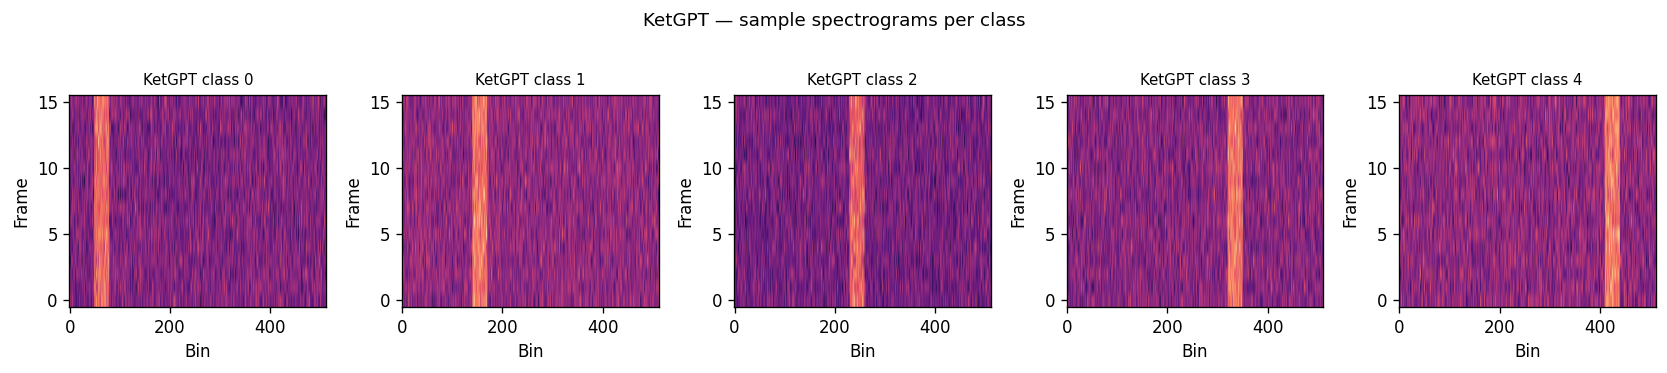

Saved ketgpt_samples.png


In [28]:
# ── Visualise 5 sample KetGPT spectrograms ──────────────────────────────────
fig, axes = plt.subplots(1, min(5, N_CLASSES_KG), figsize=(14, 3))
if N_CLASSES_KG == 1:
    axes = [axes]
for cls_idx in range(min(5, N_CLASSES_KG)):
    mask = (y_ketgpt == cls_idx)
    if mask.sum() == 0:
        continue
    sample = X_ketgpt[mask][0, 0]   # (16, 512)
    ax = axes[cls_idx]
    ax.imshow(sample, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"KetGPT class {cls_idx}", fontsize=9)
    ax.set_xlabel("Bin"); ax.set_ylabel("Frame")
plt.suptitle("KetGPT — sample spectrograms per class", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT_BASE / "ketgpt_samples.png", bbox_inches="tight")
plt.show()
print("Saved ketgpt_samples.png")


## Dataset B — Corrosion Byproducts (31 classes, physics-informed synthetic)

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET B — Corrosion Byproducts  (31-class synthetic, physics-informed)
# ══════════════════════════════════════════════════════════════════════════════
#
# Each compound is described by spectral parameters derived from its known
# crystal structure and optical / magnetic properties:
#   f_peak    — normalised centre frequency (crystal lattice spacing proxy)
#   bw        — peak bandwidth (crystallinity; narrow = well-ordered)
#   harmonics — (relative_position, relative_amplitude) overtone list
#   phase     — polymorph-specific phase offset (differentiates same-formula polymorphs)
#   snr_db    — signal-to-noise ratio (higher = more ordered)
#   metal     — parent metal group (0=Fe, 1=Cu, 2=Al, 3=Zn, 4=Ni)
#
# Crystal-structure → f_peak mapping:
#   Hexagonal      : 0.75–0.85    Cubic/spinel   : 0.60–0.72
#   Orthorhombic   : 0.50–0.60    Tetragonal     : 0.43–0.50
#   Monoclinic/rhomb: 0.40–0.50   Amorphous/LDH  : 0.25–0.38

COMPOUNDS = [
    # id  name                   metal  f_peak   bw     harmonics                           phase   snr
    # ── Iron / Steel (Fe) ────────────────────────────────────────────────────────────
    { "id":  0, "name": "Hematite (Fe₂O₃)",              "metal": 0,
      "f_peak": 0.82, "bw": 0.030, "harmonics": [(0.41, 0.30), (0.25, 0.15)],           "phase": 0.00, "snr": 22 },
    { "id":  1, "name": "Magnetite (Fe₃O₄)",             "metal": 0,
      "f_peak": 0.65, "bw": 0.040, "harmonics": [(0.325, 0.40), (0.195, 0.20)],          "phase": 0.30, "snr": 21 },
    { "id":  2, "name": "Goethite α-FeO(OH)",            "metal": 0,
      "f_peak": 0.55, "bw": 0.020, "harmonics": [(0.275, 0.25), (0.730, 0.18)],          "phase": 0.10, "snr": 23 },
    { "id":  3, "name": "Lepidocrocite γ-FeO(OH)",       "metal": 0,
      "f_peak": 0.52, "bw": 0.055, "harmonics": [(0.260, 0.30), (0.780, 0.12)],          "phase": 1.20, "snr": 20 },
    { "id":  4, "name": "Akaganeite β-FeO(OH)",          "metal": 0,
      "f_peak": 0.45, "bw": 0.032, "harmonics": [(0.225, 0.20), (0.675, 0.15)],          "phase": 2.10, "snr": 21 },
    { "id":  5, "name": "Ferrihydrite (Fe₅HO₈·4H₂O)",   "metal": 0,
      "f_peak": 0.30, "bw": 0.150, "harmonics": [(0.150, 0.40), (0.600, 0.20)],          "phase": 0.50, "snr": 16 },
    { "id":  6, "name": "Siderite (FeCO₃)",              "metal": 0,
      "f_peak": 0.70, "bw": 0.030, "harmonics": [(0.350, 0.35), (0.880, 0.12)],          "phase": 1.00, "snr": 22 },
    { "id":  7, "name": "Pyrrhotite (Fe₁₋ₓS)",           "metal": 0,
      "f_peak": 0.43, "bw": 0.060, "harmonics": [(0.215, 0.30), (0.645, 0.15)],          "phase": 1.70, "snr": 19 },
    { "id":  8, "name": "Green Rust",                    "metal": 0,
      "f_peak": 0.28, "bw": 0.120, "harmonics": [(0.140, 0.45), (0.550, 0.25)],          "phase": 0.80, "snr": 15 },
    # ── Copper (Cu) ──────────────────────────────────────────────────────────────────
    { "id":  9, "name": "Cuprite (Cu₂O)",                "metal": 1,
      "f_peak": 0.68, "bw": 0.030, "harmonics": [(0.340, 0.30), (0.200, 0.20)],          "phase": 0.00, "snr": 22 },
    { "id": 10, "name": "Tenorite (CuO)",                "metal": 1,
      "f_peak": 0.42, "bw": 0.042, "harmonics": [(0.210, 0.35), (0.630, 0.15)],          "phase": 0.50, "snr": 20 },
    { "id": 11, "name": "Malachite (Cu₂(CO₃)(OH)₂)",    "metal": 1,
      "f_peak": 0.48, "bw": 0.040, "harmonics": [(0.240, 0.40), (0.720, 0.20)],          "phase": 1.00, "snr": 21 },
    { "id": 12, "name": "Azurite (Cu₃(CO₃)₂(OH)₂)",    "metal": 1,
      "f_peak": 0.44, "bw": 0.035, "harmonics": [(0.220, 0.30), (0.660, 0.18)],          "phase": 1.50, "snr": 21 },
    { "id": 13, "name": "Brochantite (Cu₄(SO₄)(OH)₆)",  "metal": 1,
      "f_peak": 0.51, "bw": 0.040, "harmonics": [(0.255, 0.35), (0.765, 0.20)],          "phase": 2.00, "snr": 20 },
    { "id": 14, "name": "Antlerite (Cu₃(SO₄)(OH)₄)",    "metal": 1,
      "f_peak": 0.56, "bw": 0.030, "harmonics": [(0.280, 0.40), (0.840, 0.15)],          "phase": 2.50, "snr": 21 },
    { "id": 15, "name": "Atacamite (Cu₂Cl(OH)₃)",       "metal": 1,
      "f_peak": 0.58, "bw": 0.050, "harmonics": [(0.290, 0.30), (0.870, 0.10)],          "phase": 3.00, "snr": 19 },
    { "id": 16, "name": "Nantokite (CuCl)",              "metal": 1,
      "f_peak": 0.72, "bw": 0.020, "harmonics": [(0.360, 0.40), (0.215, 0.15)],          "phase": 0.20, "snr": 23 },
    # ── Aluminum (Al) ─────────────────────────────────────────────────────────────
    { "id": 17, "name": "Boehmite γ-AlO(OH)",            "metal": 2,
      "f_peak": 0.54, "bw": 0.025, "harmonics": [(0.270, 0.30), (0.810, 0.12)],          "phase": 0.30, "snr": 22 },
    { "id": 18, "name": "Gibbsite Al(OH)₃",              "metal": 2,
      "f_peak": 0.47, "bw": 0.035, "harmonics": [(0.235, 0.40), (0.700, 0.20)],          "phase": 0.70, "snr": 21 },
    { "id": 19, "name": "Bayerite α-Al(OH)₃",            "metal": 2,
      "f_peak": 0.46, "bw": 0.035, "harmonics": [(0.230, 0.40), (0.690, 0.20)],          "phase": 1.40, "snr": 21 },
    { "id": 20, "name": "Corundum (Al₂O₃)",              "metal": 2,
      "f_peak": 0.80, "bw": 0.020, "harmonics": [(0.400, 0.25), (0.240, 0.15)],          "phase": 0.00, "snr": 24 },
    { "id": 21, "name": "Diaspore α-AlO(OH)",             "metal": 2,
      "f_peak": 0.57, "bw": 0.025, "harmonics": [(0.285, 0.30), (0.855, 0.15)],          "phase": 1.10, "snr": 22 },
    # ── Zinc (Zn) ─────────────────────────────────────────────────────────────────
    { "id": 22, "name": "Zincite (ZnO)",                 "metal": 3,
      "f_peak": 0.78, "bw": 0.025, "harmonics": [(0.390, 0.30), (0.234, 0.20)],          "phase": 0.00, "snr": 23 },
    { "id": 23, "name": "Smithsonite (ZnCO₃)",           "metal": 3,
      "f_peak": 0.67, "bw": 0.030, "harmonics": [(0.335, 0.35), (0.850, 0.15)],          "phase": 0.90, "snr": 22 },
    { "id": 24, "name": "Simonkolleite",                 "metal": 3,
      "f_peak": 0.38, "bw": 0.070, "harmonics": [(0.190, 0.35), (0.570, 0.20)],          "phase": 1.30, "snr": 18 },
    { "id": 25, "name": "Hydrozincite",                  "metal": 3,
      "f_peak": 0.49, "bw": 0.045, "harmonics": [(0.245, 0.38), (0.735, 0.18)],          "phase": 1.80, "snr": 20 },
    { "id": 26, "name": "Zinc Hydroxide Zn(OH)₂",        "metal": 3,
      "f_peak": 0.41, "bw": 0.060, "harmonics": [(0.205, 0.40), (0.615, 0.20)],          "phase": 2.20, "snr": 19 },
    # ── Nickel (Ni) ───────────────────────────────────────────────────────────────
    { "id": 27, "name": "Bunsenite (NiO)",               "metal": 4,
      "f_peak": 0.71, "bw": 0.025, "harmonics": [(0.355, 0.30), (0.213, 0.20)],          "phase": 0.00, "snr": 22 },
    { "id": 28, "name": "Theophrastite Ni(OH)₂",         "metal": 4,
      "f_peak": 0.75, "bw": 0.040, "harmonics": [(0.375, 0.35), (0.225, 0.15)],          "phase": 0.60, "snr": 21 },
    { "id": 29, "name": "Gaspeite (NiCO₃)",              "metal": 4,
      "f_peak": 0.63, "bw": 0.030, "harmonics": [(0.315, 0.38), (0.800, 0.15)],          "phase": 1.20, "snr": 22 },
    { "id": 30, "name": "Millerite (NiS)",               "metal": 4,
      "f_peak": 0.40, "bw": 0.050, "harmonics": [(0.200, 0.35), (0.600, 0.20)],          "phase": 1.80, "snr": 20 },
]

N_CLASSES_CB = len(COMPOUNDS)   # 31
METAL_NAMES  = ["Fe (Iron/Steel)", "Cu (Copper)", "Al (Aluminum)", "Zn (Zinc)", "Ni (Nickel)"]
CLASS_NAMES  = [c["name"] for c in COMPOUNDS]
CLASS_METALS = [c["metal"] for c in COMPOUNDS]   # metal group index per class

print(f"Corrosion byproducts: {N_CLASSES_CB} compounds")
for metal_id, mname in enumerate(METAL_NAMES):
    ids = [c["id"] for c in COMPOUNDS if c["metal"] == metal_id]
    print(f"  {mname}: {len(ids)} compounds  (class ids {ids[0]}–{ids[-1]})")


Corrosion byproducts: 31 compounds
  Fe (Iron/Steel): 9 compounds  (class ids 0–8)
  Cu (Copper): 8 compounds  (class ids 9–16)
  Al (Aluminum): 5 compounds  (class ids 17–21)
  Zn (Zinc): 5 compounds  (class ids 22–26)
  Ni (Nickel): 4 compounds  (class ids 27–30)


In [30]:
# ── Synthetic IQ signal generation ──────────────────────────────────────────
#   Each sample is a baseband IQ signal with compound-specific spectral peaks,
#   converted to a 16×512 log-magnitude STFT spectrogram.

FFT_SIZE = 1024
N_STACKS = 16
OVERLAP  = 0.25
HOP      = int(FFT_SIZE * (1 - OVERLAP))
WIN      = get_window("hann", FFT_SIZE).astype(np.float32)
N_SAMPLES_IQ = N_STACKS * HOP + (FFT_SIZE - HOP)   # minimal IQ length

def make_iq_signal(params, rng, augment=False):
    """Generate one complex IQ sample with compound-specific spectral signature."""
    t   = np.linspace(0, 1, N_SAMPLES_IQ, dtype=np.float32)
    f_c = params["f_peak"]
    amp = 1.0
    # Main carrier
    s   = amp * np.exp(1j * (2 * np.pi * f_c * N_SAMPLES_IQ * t + params["phase"])).astype(np.complex64)
    # Harmonic overtones (encode compound-specific vibrational modes)
    for h_pos, h_amp in params["harmonics"]:
        s += (amp * h_amp) * np.exp(1j * 2 * np.pi * h_pos * N_SAMPLES_IQ * t).astype(np.complex64)
    # Bandwidth (crystal order / disorder):
    #   Narrow bandwidth → sharp peak → multiply by Gaussian envelope in freq domain
    S = np.fft.fft(s)
    freqs = np.fft.fftfreq(len(s))
    bw_envelope = np.exp(-0.5 * ((freqs - f_c) / params["bw"]) ** 2).astype(np.float32)
    for h_pos, h_amp in params["harmonics"]:
        bw_envelope += h_amp * np.exp(-0.5 * ((freqs - h_pos) / (params["bw"] * 0.8)) ** 2).astype(np.float32)
    S *= bw_envelope.astype(np.complex64)
    s  = np.fft.ifft(S).astype(np.complex64)
    # Noise (controlled by snr_db)
    snr_db  = params["snr"] + (rng.randn() * 2 if augment else 0.0)
    sig_pwr = np.mean(np.abs(s) ** 2)
    nse_pwr = sig_pwr / (10 ** (snr_db / 10))
    noise   = np.sqrt(nse_pwr / 2) * (rng.randn(len(s)) + 1j * rng.randn(len(s))).astype(np.complex64)
    return (s + noise).astype(np.complex64)

def iq_to_spectrogram(iq_sig):
    """STFT → (16, 512) log-magnitude spectrogram (same pipeline as corrosion IQ data)."""
    frames = np.empty((N_STACKS, FFT_SIZE), dtype=np.complex64)
    for i in range(N_STACKS):
        s = i * HOP
        frames[i] = iq_sig[s: s + FFT_SIZE] * WIN
    spec    = np.fft.fftshift(np.fft.fft(frames, axis=1), axes=1)
    mag     = np.abs(spec).astype(np.float32)
    spec_db = 20.0 * np.log10(mag + 1e-12)
    spec_512 = spec_db.reshape(N_STACKS, 512, 2).mean(axis=2)   # 1024→512 bins
    return spec_512

SAMPLES_PER_CLASS = 10   # base count; no augmentation
print(f"Generating {N_CLASSES_CB} × {SAMPLES_PER_CLASS} = {N_CLASSES_CB * SAMPLES_PER_CLASS:,} samples …")

rng    = np.random.RandomState(SEED)
X_cb_list, y_cb_list = [], []
for cmp in COMPOUNDS:
    for _ in range(SAMPLES_PER_CLASS):
        iq   = make_iq_signal(cmp, rng, augment=False)
        spec = iq_to_spectrogram(iq)
        X_cb_list.append(spec[None])   # (1, 16, 512)
        y_cb_list.append(cmp["id"])

X_cb = np.stack(X_cb_list).astype(np.float32)
y_cb = np.array(y_cb_list, dtype=np.int64)
np.nan_to_num(X_cb, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
print(f"Corrosion byproducts: {X_cb.shape}  labels: {dict(zip(*np.unique(y_cb, return_counts=True)))}")

Generating 31 × 10 = 310 samples …


Corrosion byproducts: (310, 1, 16, 512)  labels: {0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10, 11: 10, 12: 10, 13: 10, 14: 10, 15: 10, 16: 10, 17: 10, 18: 10, 19: 10, 20: 10, 21: 10, 22: 10, 23: 10, 24: 10, 25: 10, 26: 10, 27: 10, 28: 10, 29: 10, 30: 10}


In [31]:
# ── Standardise + split ──────────────────────────────────────────────────────
_N2, _C2, _H2, _W2 = X_cb.shape
_flat2   = X_cb.reshape(_N2, -1)
_scl2    = StandardScaler().fit_transform(_flat2)
X_cb_sc  = _scl2.reshape(_N2, _C2, _H2, _W2).astype(np.float32)

X_cb_tr, X_cb_te, y_cb_tr, y_cb_te = train_test_split(
    X_cb_sc, y_cb, test_size=0.20, random_state=SEED, stratify=y_cb
)
cb_train_loader, cb_test_loader = _make_loaders(X_cb_tr, y_cb_tr, X_cb_te, y_cb_te)
print(f"Corrosion — train: {X_cb_tr.shape}  test: {X_cb_te.shape}")
print(f"Train batches: {len(cb_train_loader)}  Test batches: {len(cb_test_loader)}")


Corrosion — train: (248, 1, 16, 512)  test: (62, 1, 16, 512)
Train batches: 7  Test batches: 2


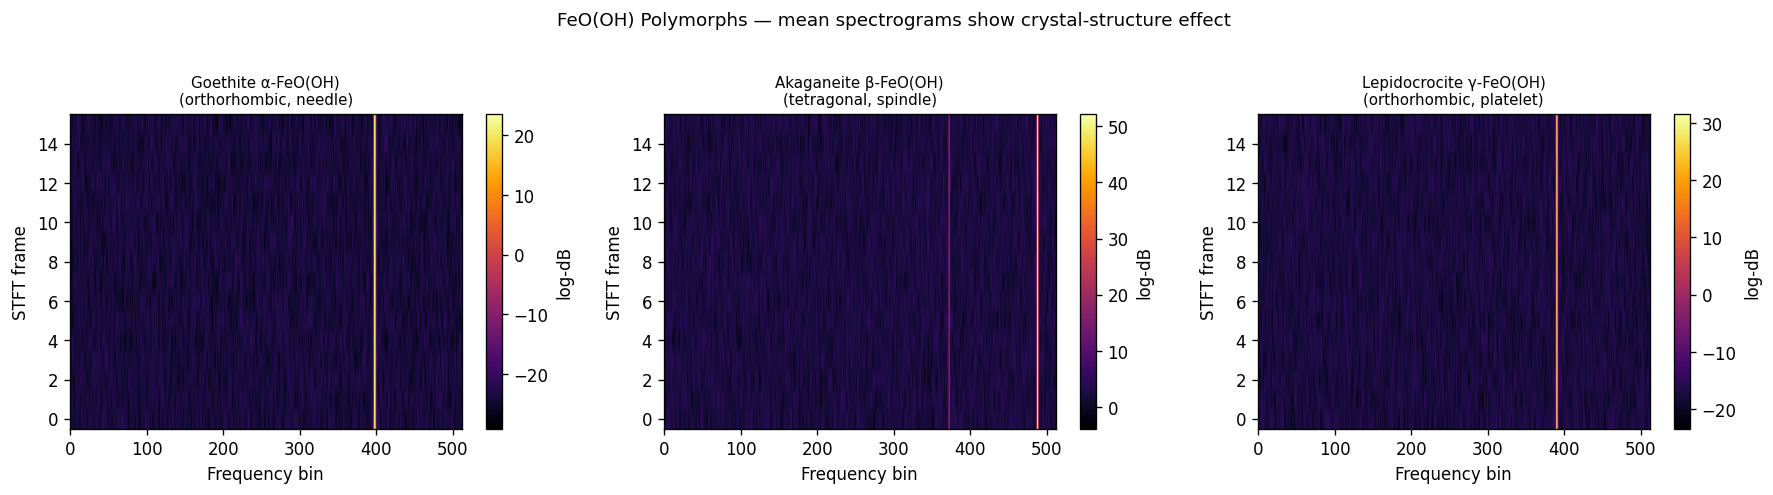

Saved polymorph_comparison.png


In [32]:
# ── Polymorph comparison: α / β / γ -FeO(OH) ────────────────────────────────
#   Same chemical formula, different crystal structure → different spectral shape
polymorph_ids  = [2, 4, 3]   # Goethite(α), Akaganeite(β), Lepidocrocite(γ)
polymorph_lbls = ["Goethite α-FeO(OH)\n(orthorhombic, needle)",
                  "Akaganeite β-FeO(OH)\n(tetragonal, spindle)",
                  "Lepidocrocite γ-FeO(OH)\n(orthorhombic, platelet)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cid, lbl in zip(axes, polymorph_ids, polymorph_lbls):
    mask   = (y_cb == cid)
    mean_s = X_cb[mask, 0].mean(axis=0)   # mean spectrogram (16, 512)
    im = ax.imshow(mean_s, aspect="auto", origin="lower", cmap="inferno")
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel("Frequency bin"); ax.set_ylabel("STFT frame")
    plt.colorbar(im, ax=ax, label="log-dB")

plt.suptitle("FeO(OH) Polymorphs — mean spectrograms show crystal-structure effect",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT_BASE / "polymorph_comparison.png", bbox_inches="tight")
plt.show()
print("Saved polymorph_comparison.png")


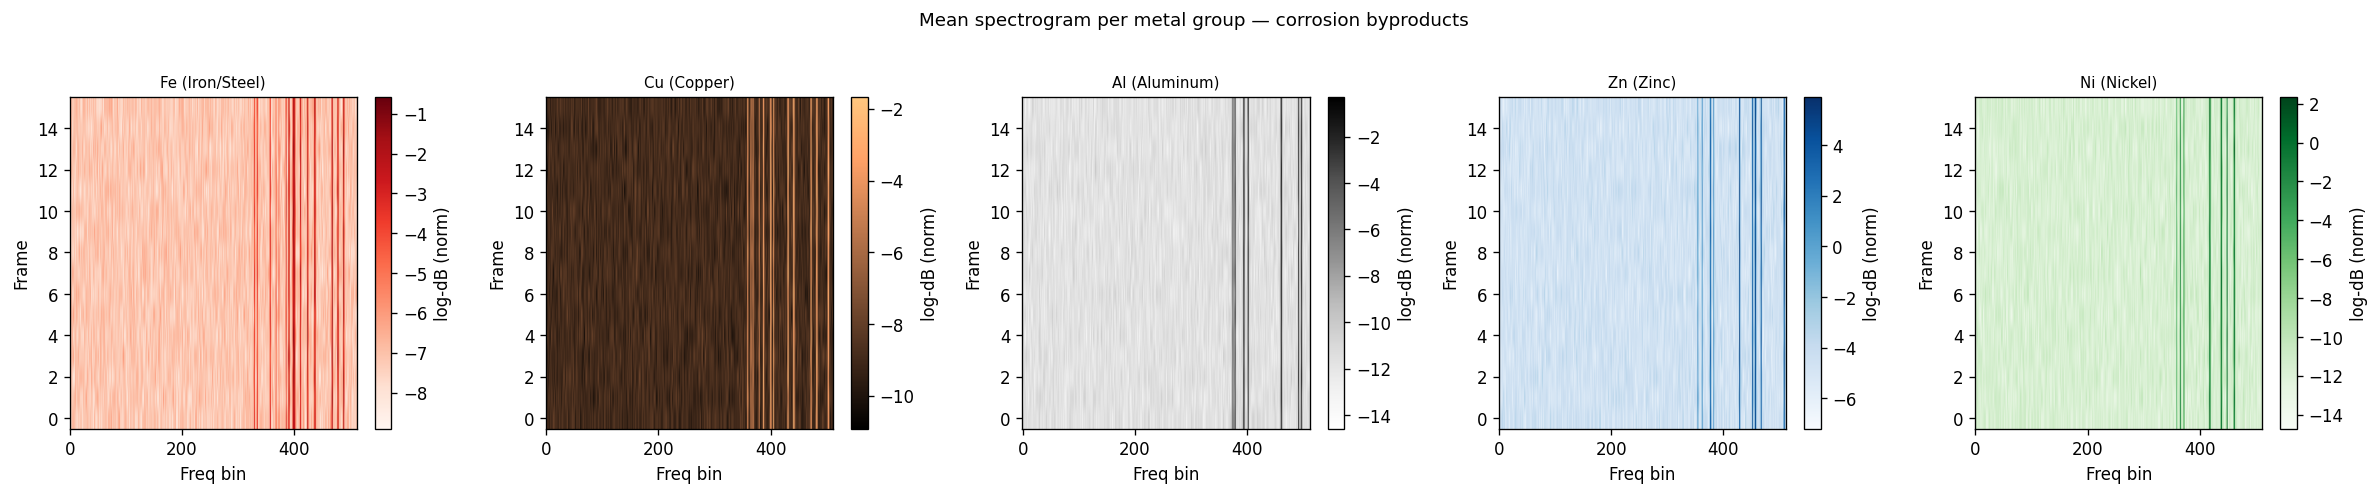

Saved metal_group_spectrograms.png


In [33]:
# ── Metal-group mean spectrogram overview ────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metal_cmaps = ["Reds", "copper", "Greys", "Blues", "Greens"]
for metal_id, (ax, mname, cmap) in enumerate(zip(axes, METAL_NAMES, metal_cmaps)):
    class_ids = [c["id"] for c in COMPOUNDS if c["metal"] == metal_id]
    mask = np.isin(y_cb, class_ids)
    mean_spec = X_cb[mask, 0].mean(axis=0)
    im = ax.imshow(mean_spec, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(mname, fontsize=9)
    ax.set_xlabel("Freq bin"); ax.set_ylabel("Frame")
    plt.colorbar(im, ax=ax, label="log-dB (norm)")

plt.suptitle("Mean spectrogram per metal group — corrosion byproducts",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT_BASE / "metal_group_spectrograms.png", bbox_inches="tight")
plt.show()
print("Saved metal_group_spectrograms.png")


Running PCA + t-SNE on corrosion byproducts features …


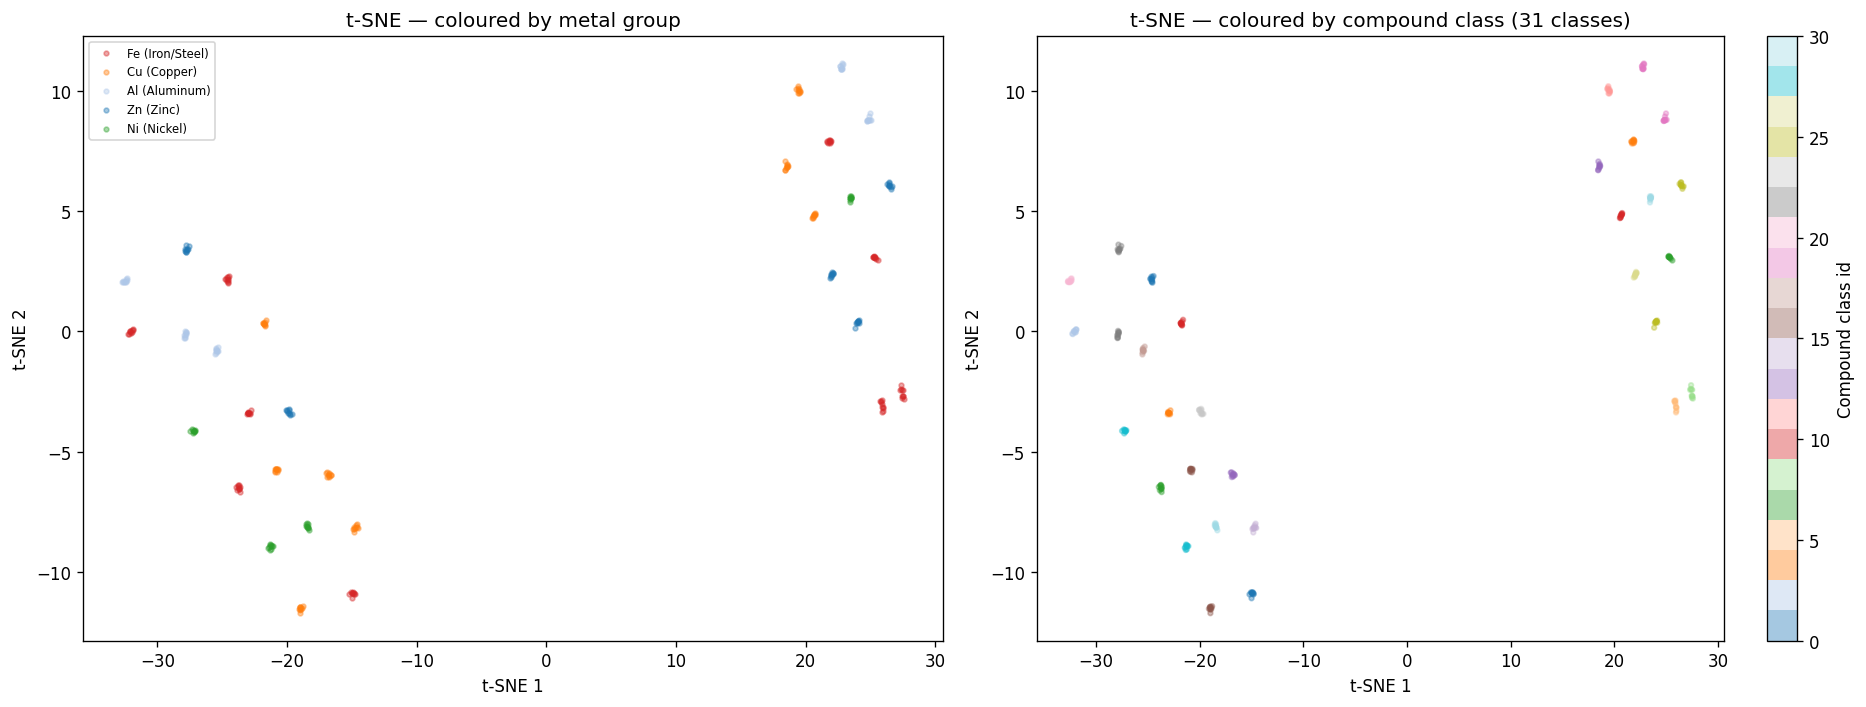

Saved tsne_features.png


In [34]:
# ── t-SNE of spectrogram features ───────────────────────────────────────────
#   PCA to 50 dims first (speeds up t-SNE), then t-SNE to 2D.
print("Running PCA + t-SNE on corrosion byproducts features …")
_X_flat = X_cb.reshape(len(X_cb), -1)
_pca    = PCA(n_components=min(50, _X_flat.shape[1]), random_state=SEED)
_X_pca  = _pca.fit_transform(_X_flat)
_tsne   = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
_X_2d   = _tsne.fit_transform(_X_pca)

# Colour by metal group
metal_colours = ["#d62728", "#ff7f0e", "#aec7e8", "#1f77b4", "#2ca02c"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for metal_id, (mname, col) in enumerate(zip(METAL_NAMES, metal_colours)):
    cids = [c["id"] for c in COMPOUNDS if c["metal"] == metal_id]
    mask = np.isin(y_cb, cids)
    ax1.scatter(_X_2d[mask, 0], _X_2d[mask, 1], c=col, label=mname,
                alpha=0.4, s=8)
ax1.set_title("t-SNE — coloured by metal group"); ax1.legend(fontsize=7)
ax1.set_xlabel("t-SNE 1"); ax1.set_ylabel("t-SNE 2")

sc = ax2.scatter(_X_2d[:, 0], _X_2d[:, 1], c=y_cb, cmap="tab20", alpha=0.4, s=8)
ax2.set_title("t-SNE — coloured by compound class (31 classes)")
ax2.set_xlabel("t-SNE 1"); ax2.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax2, label="Compound class id")

plt.tight_layout()
plt.savefig(OUT_BASE / "tsne_features.png", bbox_inches="tight")
plt.show()
print("Saved tsne_features.png")


## Model — Quantum Devices, Layers & Architecture

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# QUANTUM DEVICES & CIRCUITS  (identical to existing notebooks)
# ══════════════════════════════════════════════════════════════════════════════
def _make_device(n_q, prefer_gpu=True):
    if prefer_gpu:
        try:
            d = qp.device("lightning.gpu", wires=n_q)
            print(f"  {d.name}")
            return d, "adjoint"
        except Exception:
            pass
    d = qp.device("default.qubit", wires=n_q)
    print(f"  {d.name}")
    return d, "backprop"

print("Quantum device (real qnode):")
dev_real, diff_real = _make_device(N_QUBITS)

print("Quantum device (complex qnode):")
dev_complex = qp.device("default.qubit", wires=N_QUBITS)

@qp.qnode(dev_real, interface="torch", diff_method=diff_real)
def qnode_real(inputs, weights):
    qp.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qp.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qp.expval(qp.PauliZ(i)) for i in range(N_QUBITS)]

@qp.qnode(dev_complex, interface="torch", diff_method="backprop")
def qnode_complex(inputs, weights):
    qp.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qp.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return qp.state()   # (2^N_QUBITS,) complex

print(f"\nReal output dim : {N_QUBITS}")
print(f"Complex output dim: 2 × 2^{N_QUBITS} = {2 * 2**N_QUBITS}  (real+imag split)")


Quantum device (real qnode):
  Default qubit PennyLane plugin
Quantum device (complex qnode):

Real output dim : 4
Complex output dim: 2 × 2^4 = 32  (real+imag split)


In [36]:
class BatchedQuantumLayer(nn.Module):
    """PauliZ expectation values → (B, N_QUBITS)."""
    def __init__(self, n_l, n_q, q_node):
        super().__init__()
        self.n_qubits = n_q
        self.qnode    = q_node
        self.weights  = nn.Parameter(torch.empty(n_l, n_q).uniform_(-np.pi, np.pi))

    def forward(self, x):
        B   = x.shape[0]
        out = self.qnode(x, self.weights)
        return out.float().view(self.n_qubits, B).t().contiguous()


class BatchedQuantumLayerComplex(nn.Module):
    """Full statevector → (B, 2·2^N_QUBITS) float (real∥imag)."""
    def __init__(self, n_l, n_q, q_node):
        super().__init__()
        self.n_qubits  = n_q
        self.state_dim = 2 ** n_q
        self.qnode     = q_node
        self.weights   = nn.Parameter(torch.empty(n_l, n_q).uniform_(-np.pi, np.pi))

    def forward(self, x):
        B   = x.shape[0]
        out = self.qnode(x, self.weights)
        if out.dim() == 1:
            out = out.unsqueeze(0)
        if out.shape[0] != B:
            out = out.t()
        return torch.cat([out.real.float(), out.imag.float()], dim=-1).contiguous()


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# FUSION MODULE — FreqDomainFusion  (FFT best: product × complex × gelu)
# ══════════════════════════════════════════════════════════════════════════════
#
#   c (B, 64) ──proj_c──► rfft ─┐
#                                ├─ product ─► irfft ─► LayerNorm ─► GELU ─► logits
#   q (B, 32) ──proj_q──► rfft ─┘
#
# `product` = complex element-wise multiplication ≡ cross-correlation in spatial domain.
# Complex quantum statevector (real∥imag, 32-dim) preserves amplitude & phase.

class FreqDomainFusion(nn.Module):
    def __init__(self, c_dim, q_dim, d_fft, n_classes,
                 fusion_op="product", final_act="gelu"):
        super().__init__()
        self.d_fft     = d_fft
        self.fusion_op = fusion_op
        self.proj_c    = nn.Linear(c_dim, d_fft)
        self.proj_q    = nn.Linear(q_dim, d_fft)
        self.norm      = nn.LayerNorm(d_fft)
        _acts = {"relu": nn.ReLU(), "gelu": nn.GELU(), "softmax": nn.Softmax(dim=-1)}
        self.act        = _acts[final_act]
        self.classifier = nn.Linear(d_fft, n_classes)

    def forward(self, c, q):
        C = torch.fft.rfft(self.proj_c(c), dim=-1)
        Q = torch.fft.rfft(self.proj_q(q), dim=-1)
        F = C * Q if self.fusion_op == "product" else C + Q
        f = torch.fft.irfft(F, n=self.d_fft, dim=-1)
        return self.classifier(self.act(self.norm(f)))

QUANTUM_TYPE = "complex"
FUSION_TYPE  = "fft"
FUSION_OP    = "product"
FINAL_ACT    = "gelu"
FUSION_LABEL = "FFT best (fft · complex · product · gelu)"
Q_DIM        = 2 * (2 ** N_QUBITS)   # 32

def _build_fusion(n_classes):
    return FreqDomainFusion(
        c_dim=64, q_dim=Q_DIM, d_fft=D_FUSION,
        n_classes=n_classes, fusion_op=FUSION_OP, final_act=FINAL_ACT
    )

print(f"Fusion: {FUSION_LABEL}")
print(f"  c_dim=64  q_dim={Q_DIM}  d_fft={D_FUSION}  n_classes=<variable>")


Fusion: FFT best (fft · complex · product · gelu)
  c_dim=64  q_dim=32  d_fft=64  n_classes=<variable>


In [38]:
# ── Unified HybridQNN_Alt (pluggable fusion, configurable n_classes) ─────────
class HybridQNN_Alt(nn.Module):
    """
    CNN backbone → quantum branch + classical skip → fusion → logits.

    Input : (B, 1, 16, 512)
    Output: (B, n_classes)

    `fusion_module` is injected at construction time (dependency injection).
    `n_classes` is passed to the fusion module; pass it when instantiating fusion.
    """
    def __init__(self, fusion_module, quantum_type="real",
                 dropout_cnn=0.2350, dropout_skip=0.2012):
        super().__init__()
        self.quantum_type = quantum_type
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 128, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_cnn),
        )
        self.qnn_proj = nn.Sequential(nn.Linear(256, N_QUBITS), nn.Sigmoid())
        if quantum_type == "complex":
            self.qnn  = BatchedQuantumLayerComplex(N_LAYERS, N_QUBITS, qnode_complex)
            self.q_dim = 2 * (2 ** N_QUBITS)   # 32
        else:
            self.qnn  = BatchedQuantumLayer(N_LAYERS, N_QUBITS, qnode_real)
            self.q_dim = N_QUBITS               # 4
        self.classical_skip = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout_skip),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(dropout_skip),
        )
        self.fusion = fusion_module

    def forward(self, x):
        feat  = self.cnn(x)
        q_in  = self.qnn_proj(feat) * (2.0 * math.pi)
        q_out = self.qnn(q_in)
        c_out = self.classical_skip(feat)
        return self.fusion(c_out, q_out)


In [39]:
# ── Training utility (same convergence settings as existing notebooks) ────────
def train_one(model, train_loader, test_loader, n_classes,
              max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True, tag=""):
    """Train model and return best-checkpoint metrics dict."""
    set_seed(SEED)
    class_counts = np.bincount(train_loader.dataset.tensors[1].numpy(), minlength=n_classes)
    cw = 1.0 / np.maximum(class_counts, 1).astype(np.float32)
    cw = cw / cw.sum() * n_classes
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(device))
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE
    )
    best_f1 = 0.0; best_w = None; best_ep = 0; no_impr = 0
    t0 = time.time()
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            nn.CrossEntropyLoss(weight=criterion.weight)(model(xb), yb).backward()
            optimizer.step()
        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
                tgts.extend(yb.numpy())
        f1 = f1_score(tgts, preds, average="macro", zero_division=0)
        scheduler.step(f1)
        if f1 > best_f1:
            best_f1 = f1; best_w = copy.deepcopy(model.state_dict())
            best_ep = epoch + 1; no_impr = 0
        else:
            no_impr += 1
        if verbose:
            mark = " ←" if no_impr == 0 else ""
            print(f"  [{tag}] ep {epoch+1:02d}/{max_epochs}  f1={f1:.4f}{mark}  "
                  f"({time.time()-t0:.0f}s)")
        if no_impr >= patience:
            break
    # Final eval with best checkpoint
    model.load_state_dict(best_w)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            tgts.extend(yb.numpy())
    return {
        "val_acc":     accuracy_score(tgts, preds),
        "macro_f1":    f1_score(tgts, preds, average="macro",    zero_division=0),
        "weighted_f1": f1_score(tgts, preds, average="weighted", zero_division=0),
        "best_epoch":  best_ep,
        "total_epochs": epoch + 1,
        "preds": preds, "tgts": tgts,
    }


## Train & Evaluate — KetGPT

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN & EVALUATE — KetGPT
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print(f"KetGPT  (n_classes={N_CLASSES_KG})")
print("=" * 65)

set_seed(SEED)
_kg_fusion = _build_fusion(N_CLASSES_KG)
kg_model   = HybridQNN_Alt(_kg_fusion, quantum_type=QUANTUM_TYPE).to(device)
n_params   = sum(p.numel() for p in kg_model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")

# Smoke test
with torch.no_grad():
    _x = next(iter(kg_train_loader))[0][:2].to(device)
    print(f"Smoke test output: {kg_model(_x).shape}")

kg_metrics = train_one(kg_model, kg_train_loader, kg_test_loader,
                        n_classes=N_CLASSES_KG, tag="KetGPT")

print(f"\nKetGPT Results:")
print(f"  Accuracy   : {kg_metrics['val_acc']:.4f}")
print(f"  Macro F1   : {kg_metrics['macro_f1']:.4f}")
print(f"  Weighted F1: {kg_metrics['weighted_f1']:.4f}")
print(f"  Best epoch : {kg_metrics['best_epoch']} / {kg_metrics['total_epochs']}")


KetGPT  (n_classes=5)
Trainable params: 4,248,889


Smoke test output: torch.Size([2, 5])
  [KetGPT] ep 01/30  f1=1.0000 ←  (7s)
  [KetGPT] ep 02/30  f1=1.0000  (15s)
  [KetGPT] ep 03/30  f1=1.0000  (22s)
  [KetGPT] ep 04/30  f1=1.0000  (29s)
  [KetGPT] ep 05/30  f1=1.0000  (37s)
  [KetGPT] ep 06/30  f1=1.0000  (44s)

KetGPT Results:
  Accuracy   : 1.0000
  Macro F1   : 1.0000
  Weighted F1: 1.0000
  Best epoch : 1 / 6


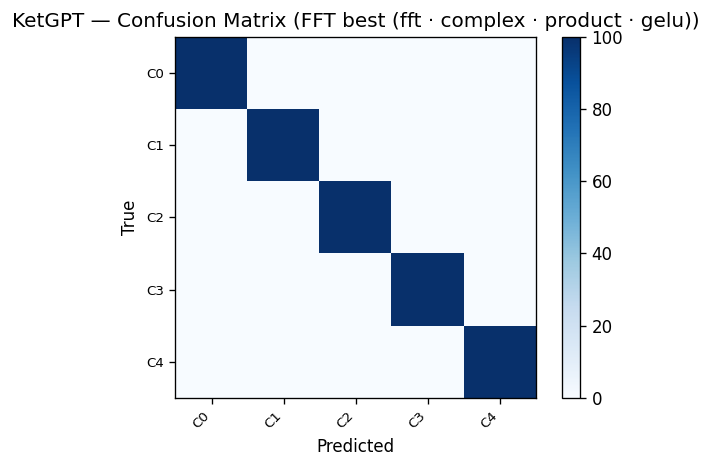

Saved ketgpt_confusion_matrix.png


In [41]:
# ── KetGPT confusion matrix ──────────────────────────────────────────────────
_kg_cm = confusion_matrix(kg_metrics["tgts"], kg_metrics["preds"])
fig, ax = plt.subplots(figsize=(max(5, N_CLASSES_KG), max(4, N_CLASSES_KG - 1)))
im = ax.imshow(_kg_cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"KetGPT — Confusion Matrix ({FUSION_LABEL})")
tick_marks = np.arange(N_CLASSES_KG)
ax.set_xticks(tick_marks); ax.set_yticks(tick_marks)
ax.set_xticklabels([f"C{i}" for i in range(N_CLASSES_KG)], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([f"C{i}" for i in range(N_CLASSES_KG)], fontsize=8)
plt.tight_layout()
plt.savefig(OUT_BASE / "ketgpt_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("Saved ketgpt_confusion_matrix.png")


## Train & Evaluate — Corrosion Byproducts

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN & EVALUATE — Corrosion Byproducts  (31 classes)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print(f"Corrosion Byproducts  (n_classes={N_CLASSES_CB})")
print("=" * 65)

set_seed(SEED)
_cb_fusion = _build_fusion(N_CLASSES_CB)
cb_model   = HybridQNN_Alt(_cb_fusion, quantum_type=QUANTUM_TYPE).to(device)
n_params2  = sum(p.numel() for p in cb_model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params2:,}")

with torch.no_grad():
    _x2 = next(iter(cb_train_loader))[0][:2].to(device)
    print(f"Smoke test output: {cb_model(_x2).shape}")

cb_metrics = train_one(cb_model, cb_train_loader, cb_test_loader,
                        n_classes=N_CLASSES_CB, tag="Corrosion")

print(f"\nCorrosion Byproducts Results:")
print(f"  Accuracy   : {cb_metrics['val_acc']:.4f}")
print(f"  Macro F1   : {cb_metrics['macro_f1']:.4f}")
print(f"  Weighted F1: {cb_metrics['weighted_f1']:.4f}")
print(f"  Best epoch : {cb_metrics['best_epoch']} / {cb_metrics['total_epochs']}")


Corrosion Byproducts  (n_classes=31)
Trainable params: 4,250,579
Smoke test output: torch.Size([2, 31])
  [Corrosion] ep 01/30  f1=0.0213 ←  (1s)
  [Corrosion] ep 02/30  f1=0.0392 ←  (2s)
  [Corrosion] ep 03/30  f1=0.0918 ←  (3s)
  [Corrosion] ep 04/30  f1=0.2895 ←  (4s)
  [Corrosion] ep 05/30  f1=0.5226 ←  (4s)
  [Corrosion] ep 06/30  f1=0.9828 ←  (5s)
  [Corrosion] ep 07/30  f1=1.0000 ←  (6s)
  [Corrosion] ep 08/30  f1=1.0000  (7s)
  [Corrosion] ep 09/30  f1=1.0000  (8s)
  [Corrosion] ep 10/30  f1=1.0000  (9s)
  [Corrosion] ep 11/30  f1=1.0000  (10s)
  [Corrosion] ep 12/30  f1=1.0000  (10s)

Corrosion Byproducts Results:
  Accuracy   : 1.0000
  Macro F1   : 1.0000
  Weighted F1: 1.0000
  Best epoch : 7 / 12


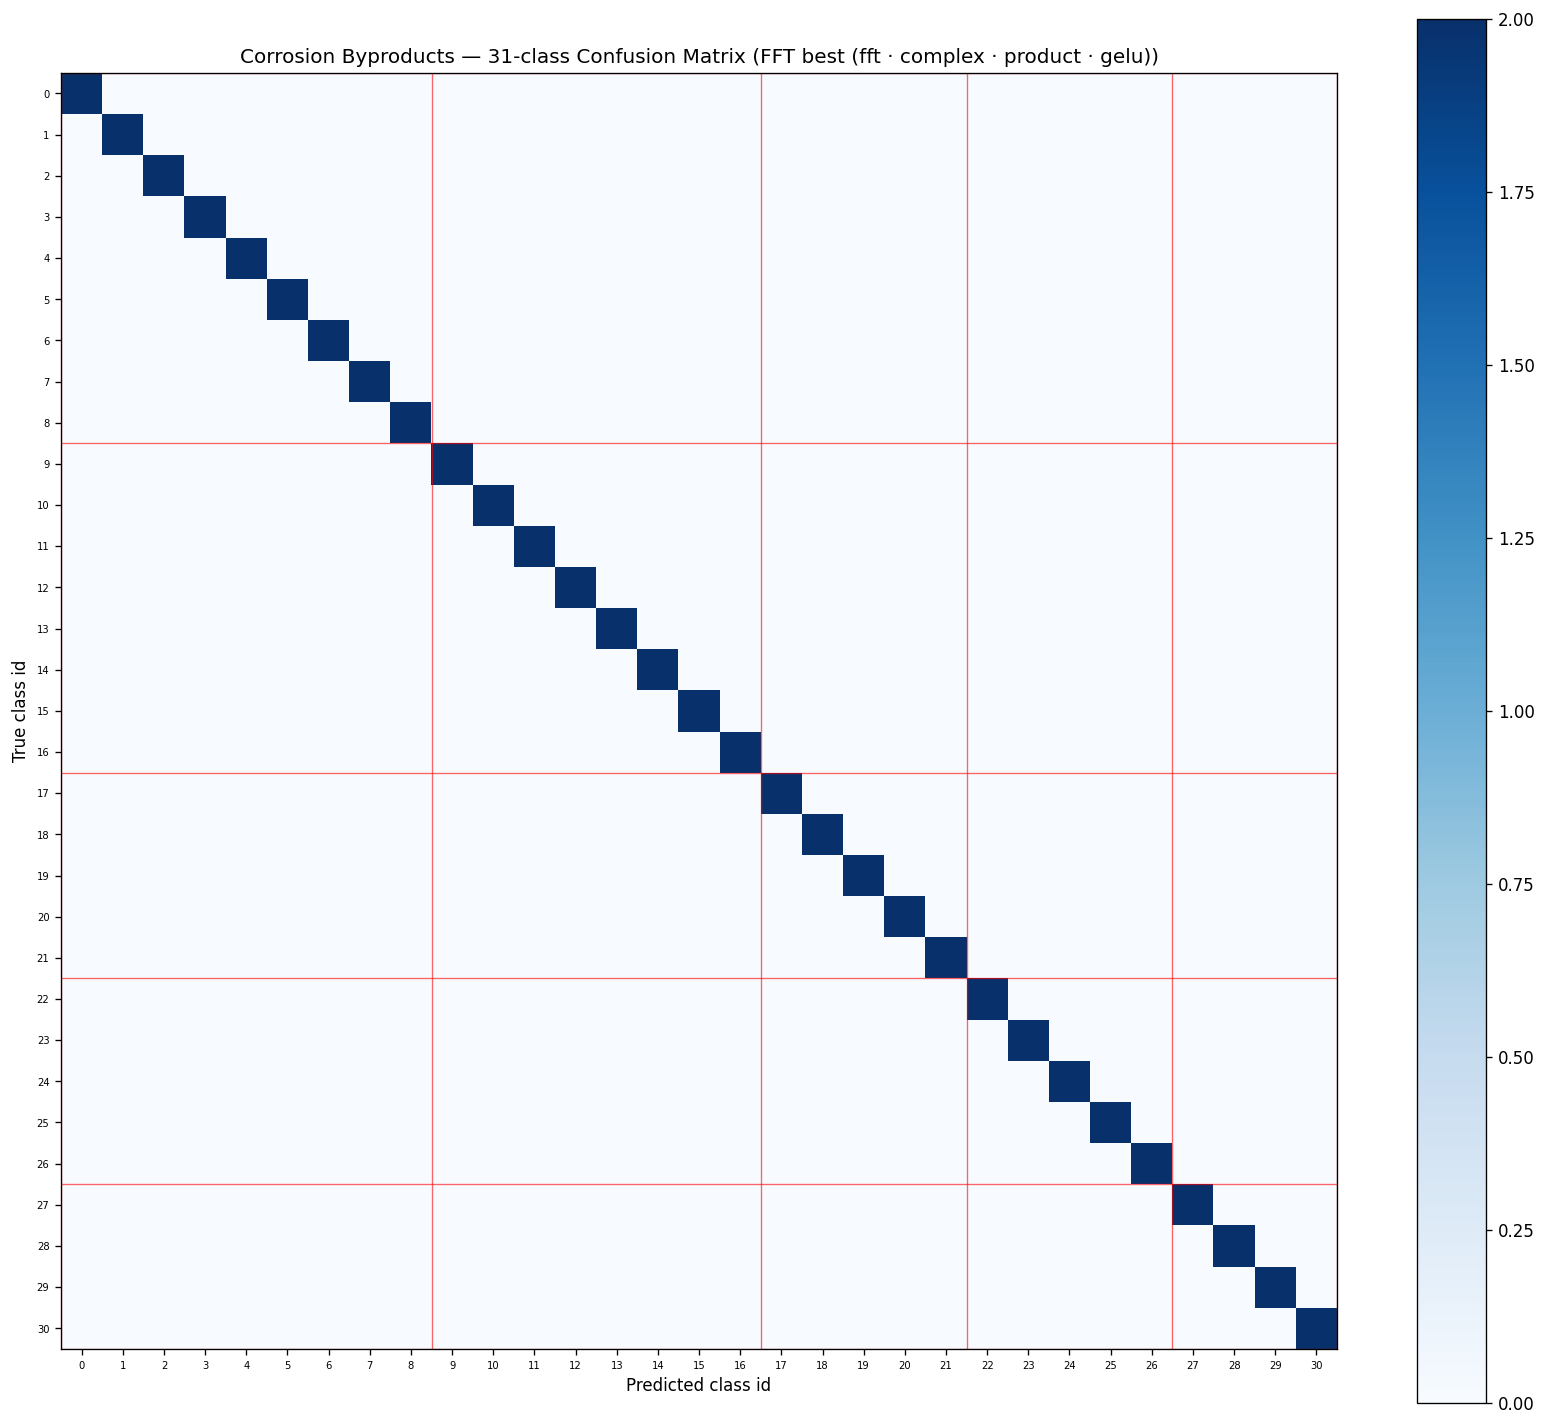

Saved corrosion_confusion_matrix.png


In [43]:
# ── Corrosion confusion matrix (31×31) ──────────────────────────────────────
_cb_cm = confusion_matrix(cb_metrics["tgts"], cb_metrics["preds"])
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(_cb_cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xlabel("Predicted class id"); ax.set_ylabel("True class id")
ax.set_title(f"Corrosion Byproducts — 31-class Confusion Matrix ({FUSION_LABEL})")
ticks = np.arange(N_CLASSES_CB)
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels(ticks, fontsize=6); ax.set_yticklabels(ticks, fontsize=6)
# Annotate metal-group boundaries
metal_boundaries = [0, 9, 17, 22, 27, 31]
for b in metal_boundaries:
    ax.axhline(b - 0.5, color="red", linewidth=0.8, alpha=0.6)
    ax.axvline(b - 0.5, color="red", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig(OUT_BASE / "corrosion_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("Saved corrosion_confusion_matrix.png")



Per-metal macro F1 (class-level predictions mapped to metal group):
  Fe (Iron/Steel)       : F1=1.0000  (n=18)
  Cu (Copper)           : F1=1.0000  (n=16)
  Al (Aluminum)         : F1=1.0000  (n=10)
  Zn (Zinc)             : F1=1.0000  (n=10)
  Ni (Nickel)           : F1=1.0000  (n=8)


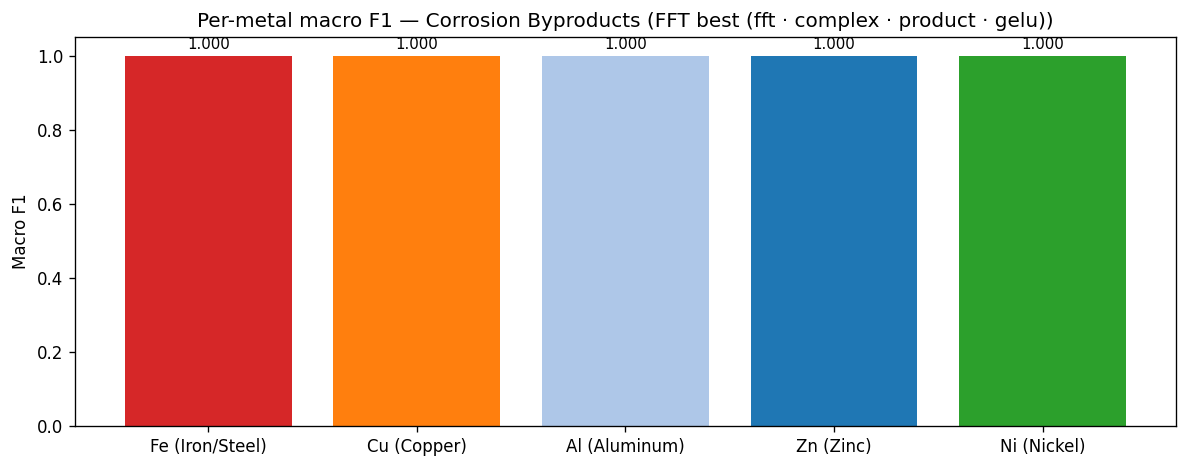

Saved per_metal_f1.png


In [44]:
# ── Per-metal F1 breakdown ───────────────────────────────────────────────────
#   Aggregate predictions by metal group to see which metals are easiest/hardest.
_preds = np.array(cb_metrics["preds"]); _tgts = np.array(cb_metrics["tgts"])
_metal_tgts  = np.array(CLASS_METALS)[_tgts]
_metal_preds = np.array(CLASS_METALS)[_preds]

print("\nPer-metal macro F1 (class-level predictions mapped to metal group):")
metal_f1s = []
for metal_id, mname in enumerate(METAL_NAMES):
    mask = (_metal_tgts == metal_id)
    if mask.sum() == 0:
        metal_f1s.append(0.0)
        continue
    class_ids = [c["id"] for c in COMPOUNDS if c["metal"] == metal_id]
    f1_m = f1_score(_tgts[mask], _preds[mask],
                    labels=class_ids, average="macro", zero_division=0)
    metal_f1s.append(f1_m)
    print(f"  {mname:22s}: F1={f1_m:.4f}  (n={mask.sum()})")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(METAL_NAMES, metal_f1s, color=["#d62728","#ff7f0e","#aec7e8","#1f77b4","#2ca02c"])
ax.set_ylim(0, 1.05); ax.set_ylabel("Macro F1")
ax.set_title(f"Per-metal macro F1 — Corrosion Byproducts ({FUSION_LABEL})")
for bar, f1v in zip(bars, metal_f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{f1v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_BASE / "per_metal_f1.png", bbox_inches="tight")
plt.show()
print("Saved per_metal_f1.png")


## Summary

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY — side-by-side comparison
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print(f"SUMMARY  —  {FUSION_LABEL}")
print("=" * 65)
print(f"{'Dataset':<30} {'Acc':>7} {'Macro F1':>10} {'Wt F1':>8} {'Best Ep':>8}")
print("-" * 65)
for dname, m in [("KetGPT", kg_metrics), ("Corrosion Byproducts (31)", cb_metrics)]:
    print(f"{dname:<30} {m['val_acc']:7.4f} {m['macro_f1']:10.4f} "
          f"{m['weighted_f1']:8.4f} {m['best_epoch']:8d}/{m['total_epochs']}")
print("=" * 65)

# Reference baselines (from original corrosion IQ dataset):
print("\nReference baselines (original 5-class corrosion IQ dataset):")
print("  FFT best  (fusion=fft, quantum=complex, kernel=product): 0.9717 macro F1")
print("  FiLM base (fusion=film, quantum=real):                    0.9566 macro F1")



SUMMARY  —  FFT best (fft · complex · product · gelu)
Dataset                            Acc   Macro F1    Wt F1  Best Ep
-----------------------------------------------------------------
KetGPT                          1.0000     1.0000   1.0000        1/6
Corrosion Byproducts (31)       1.0000     1.0000   1.0000        7/12

Reference baselines (original 5-class corrosion IQ dataset):
  FFT best  (fusion=fft, quantum=complex, kernel=product): 0.9717 macro F1
  FiLM base (fusion=film, quantum=real):                    0.9566 macro F1


In [46]:
# ── Save results CSV ────────────────────────────────────────────────────────
results_df = pd.DataFrame([
    {
        "fusion":       FUSION_TYPE,
        "quantum":      QUANTUM_TYPE,
        "kernel":       FUSION_OP if "FFT" in FUSION_LABEL else "n/a",
        "dataset":      "ketgpt",
        "n_classes":    N_CLASSES_KG,
        "val_acc":      kg_metrics["val_acc"],
        "macro_f1":     kg_metrics["macro_f1"],
        "weighted_f1":  kg_metrics["weighted_f1"],
        "best_epoch":   kg_metrics["best_epoch"],
        "total_epochs": kg_metrics["total_epochs"],
    },
    {
        "fusion":       FUSION_TYPE,
        "quantum":      QUANTUM_TYPE,
        "kernel":       FUSION_OP if "FFT" in FUSION_LABEL else "n/a",
        "dataset":      "corrosion_byproducts",
        "n_classes":    N_CLASSES_CB,
        "val_acc":      cb_metrics["val_acc"],
        "macro_f1":     cb_metrics["macro_f1"],
        "weighted_f1":  cb_metrics["weighted_f1"],
        "best_epoch":   cb_metrics["best_epoch"],
        "total_epochs": cb_metrics["total_epochs"],
    },
])
csv_path = OUT_BASE / "fft_best_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")
print(results_df.to_string(index=False))



Results saved to: /home/sammarv/quantum_corrosion/results/fft_best/fft_best_results.csv
fusion quantum  kernel              dataset  n_classes  val_acc  macro_f1  weighted_f1  best_epoch  total_epochs
   fft complex product               ketgpt          5      1.0       1.0          1.0           1             6
   fft complex product corrosion_byproducts         31      1.0       1.0          1.0           7            12
